
TFG

Este es el codigo del tfg de Borja Jimeno

In [147]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm

import re

sys.path.append('../../')

sys.path.append('../QF_Tamara')
sys.path.append('../QF_DAMA')



from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [148]:

import sys            
import os             
import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
import re
import numpy as np
import uproot


def carga_datos_hist(titulo,archivo):
    file = uproot.open(archivo)
    file.keys()
    longitud=36*4
    datos=np.zeros((2,longitud))
    
    graph = file[titulo]
    datos[0]=graph.member("fX")
    datos[1]=graph.member("fY")
    
    return datos


Datos_DM_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI","../QF_Tamara/SI_fix_1.root")
Datos_DM_16_ANOD=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_ANOD_DM_SG_SI","../QF_Tamara/SI_fix_1.root")

DM_16=Datos_DM_16[1]
DM_16_ANOD=Datos_DM_16_ANOD[1]

DM_16_m=Datos_DM_16[0]
DM_16_ANOD_m=Datos_DM_16_ANOD[0]


Datos_DM_26=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_DM_SG_SI","../QF_Tamara/SI_fix_1.root")
Datos_DM_26_ANOD=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFtamara_ANOD_DM_SG_SI","../QF_Tamara/SI_fix_1.root")

DM_26=Datos_DM_26[1]
DM_26_ANOD=Datos_DM_26_ANOD[1]

DM_26_m=Datos_DM_26[0]
DM_26_ANOD_m=Datos_DM_26_ANOD[0]

masas_ref=Datos_DM_26[0]

Datos_DM_8y_16=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFtamara_DM_SG_SI;4","../QF_Tamara/SI_8y.root")

DM_16_8y=Datos_DM_8y_16[1]

DM_16_8y_m=Datos_DM_8y_16[0]



In [149]:
Datos_DM_16_ANOD_D=carga_datos_hist("gA112_6y_90_1.000000_6.000000_QFdama_ANOD_DM_SG_SI","../QF_DAMA/Qf_DAMA.root")

DM_16_ANOD_D=Datos_DM_16_ANOD_D[1]

DM_16_ANOD_m_D=Datos_DM_16_ANOD_D[0]

Datos_DM_26_ANOD_D=carga_datos_hist("gA112_6y_90_2.000000_6.000000_QFdama_ANOD_DM_SG_SI","../QF_DAMA/Qf_DAMA.root")


DM_26_ANOD_D=Datos_DM_26_ANOD_D[1]

DM_26_ANOD_m_D=Datos_DM_26_ANOD_D[0]



In [150]:
def elimina_sing(array_d,array_m):
    aa=0
    while(aa==0):
        if (array_d[0]<0 or array_d[0]>1):
            array_d=np.delete(array_d,0)
            array_m=np.delete(array_m,0)
        else:
            aa=1
    return array_d,array_m

DM_16, DM_16_m = elimina_sing(DM_16,DM_16_m)

DM_16_ANOD, DM_16_ANOD_m = elimina_sing(DM_16_ANOD,DM_16_ANOD_m)

DM_26, DM_26_m = elimina_sing(DM_26,DM_26_m)

DM_26_ANOD, DM_26_ANOD_m = elimina_sing(DM_26_ANOD,DM_26_ANOD_m)

DM_16_8y, DM_16_8y_m = elimina_sing(DM_16_8y,DM_16_8y_m)


DM_16_ANOD_D, DM_16_ANOD_m_D = elimina_sing(DM_16_ANOD_D,DM_16_ANOD_m_D)


DM_26_ANOD_D, DM_26_ANOD_m_D = elimina_sing(DM_26_ANOD_D,DM_26_ANOD_m_D)





In [151]:
DAMA1=np.loadtxt("../QF_Tamara/DAMA1.txt")

DAMA1_x=[]
DAMA1_y=[]

for i in range(len(DAMA1)):
    DAMA1_x.append(DAMA1[i][0])
    DAMA1_y.append(DAMA1[i][1])

DAMA2=np.loadtxt("../QF_Tamara/DAMA2.txt")

DAMA2_x=[]
DAMA2_y=[]

for i in range(len(DAMA2)):
    DAMA2_x.append(DAMA2[i][0])
    DAMA2_y.append(DAMA2[i][1])



COSINE=np.loadtxt("../QF_Tamara/COSINE-100.txt")

COSINE_x=[]
COSINE_y=[]

for i in range(len(COSINE)):
    COSINE_x.append(COSINE[i][0])
    COSINE_y.append(COSINE[i][1])

ANAIS_SF=np.loadtxt("../QF_Tamara/SI_SF.txt")

ANAIS_SF_x=[]
ANAIS_SF_y=[]

for i in range(len(ANAIS_SF)):
    ANAIS_SF_x.append(ANAIS_SF[i][0])
    ANAIS_SF_y.append(ANAIS_SF[i][1])


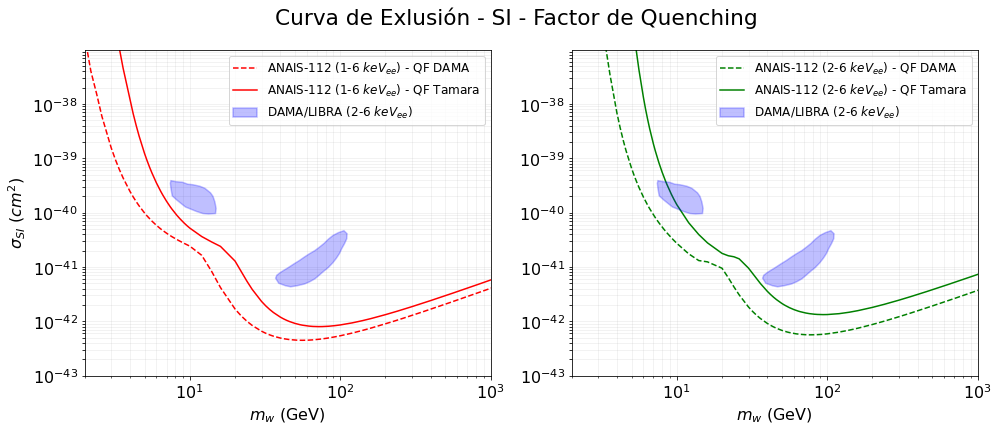

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


LABEL_SIZE = 16
TICK_SIZE  = 16


ax = axes[0]
ax.set_facecolor('white')  # Fondo blanco del área de los ejes



ax.plot(DM_16_ANOD_m_D,DM_16_ANOD_D, linestyle='--',label="ANAIS-112 (1-6 $keV_{ee}$) - QF DAMA", alpha=1,c="red")
ax.plot(DM_16_ANOD_m,DM_16_ANOD, linestyle='-',label="ANAIS-112 (1-6 $keV_{ee}$) - QF Tamara", alpha=1,c="red")

ax.fill(DAMA1_x, DAMA1_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2-6 $keV_{ee}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5)

ax.legend(fontsize=12)

ax.tick_params(axis='both', which='both', labelsize=TICK_SIZE)
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=LABEL_SIZE)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=LABEL_SIZE)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)


ax = axes[1]

ax.set_facecolor('white')  # Fondo blanco del área de los ejes

ax.plot(DM_26_ANOD_m_D,DM_26_ANOD_D, linestyle='--',label="ANAIS-112 (2-6 $keV_{ee}$) - QF DAMA", alpha=1,c="green")


ax.plot(DM_26_ANOD_m,DM_26_ANOD, linestyle='-',label="ANAIS-112 (2-6 $keV_{ee}$) - QF Tamara", alpha=1,c="green")

ax.fill(DAMA1_x, DAMA1_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2-6 $keV_{ee}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue',zorder=10, alpha=0.25, edgecolor='blue', linewidth=1.5)

ax.legend(fontsize=12)

ax.tick_params(axis='both', which='both', labelsize=TICK_SIZE)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=LABEL_SIZE)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-43

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

fig.suptitle(r'Curva de Exlusión - SI - Factor de Quenching')
plt.savefig("VariacionQF.pdf", dpi=150, facecolor='white',bbox_inches='tight')


In [153]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a

def lista_intervalo(lista_energias,anod_bool):
    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFtamara_"
    
    if anod_bool==0:
        modos="DM_SG_SI"

    if anod_bool==1:
        modos="ANOD_DM_SG_SI"
    

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(2)
            list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos)
            intervalo_minimo[0]=lista_energias[i][0]
            intervalo_minimo[1]=lista_energias[i][1]
            list_energies.append(intervalo_minimo)


    return list_names, list_energies

def carga_datos_hist(lista_energias,anod_bool,filename):

    lista_nombres, list_energies=lista_intervalo(lista_energias,anod_bool)
    
    file = uproot.open(filename)
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        
        masas=graph.member("fX")
        valores=graph.member("fY")

        valores, masas = elimina_sing(valores,masas)

        aux=np.ones((2,len(valores)))

        aux[0]=masas
        aux[1]=valores

        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado, lista_nombres

def minimiza_lista_datos(lista_datos,lista_energias,array_masas):
    
    
    masas=[]
    sigmas=[]
    int_min=[]

   

    for m in masas_ref:
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(2)
        
        for j in range (len(lista_datos[1])):
            a=0

            a=np.where(lista_datos[0][j][0]==m,lista_datos[0][j][1],0)
            a_norm=np.linalg.norm(a)

            if(a_norm!=0):
                masa_ref=1
                if(a_norm<sigma_aux):
                    sigma_aux=a_norm
                    intervalo_minimo[0]=lista_energias[j][0]
                    intervalo_minimo[1]=lista_energias[j][1]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(m)
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min

def imprime_intervalo_optimo(masas,intervalo_minimo):
    for i in range (len(masas)):
        print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV ')

In [154]:
lista_energias= np.loadtxt('../QF_Tamara/list_energies_SI.txt')

lista_datos, lista_nombres=carga_datos_hist(lista_energias,0,'../QF_Tamara/SI_int_1.root')

masas_opt,sigmas_opt,intervalo_minimo=minimiza_lista_datos(lista_datos,lista_energias,masas_ref)

imprime_intervalo_optimo(masas_opt,intervalo_minimo)

Mass: 2.2 GeV - Minimum Exlussion Interval:  (2.0 - 3.0) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (2.0 - 5.0) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (2.0 - 6.0) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (2.0 - 3.0) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

In [155]:
lista_energias_ANOD = np.loadtxt('../QF_Tamara/list_energies_SI_ANOD.txt')

lista_datos_ANOD, lista_nombres_ANOD=carga_datos_hist(lista_energias_ANOD,1,'../QF_Tamara/SI_int_1.root')

masas_opt_ANOD,sigmas_opt_ANOD,intervalo_minimo_ANOD=minimiza_lista_datos(lista_datos_ANOD,lista_energias_ANOD,masas_ref)

imprime_intervalo_optimo(masas_opt_ANOD,intervalo_minimo_ANOD)

Mass: 2.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

In [156]:
print(intervalo_minimo_ANOD)

def genera_masas_intervalos(intervalo_minimo,masas):

    m_crit_aux=[]
    m_crit=[]
    i_crit=[]

    min_aux=intervalo_minimo[0][0]
    max_aux=intervalo_minimo[0][1]

    aux_1=np.zeros(2)
    aux_1[0]=min_aux
    aux_1[1]=max_aux
    i_crit.append(aux_1)

    for i in range (len(intervalo_minimo)):

        if(intervalo_minimo[i][0]!=min_aux or intervalo_minimo[i][1]!=max_aux):

            min_aux=intervalo_minimo[i][0]
            max_aux=intervalo_minimo[i][1]

            aux_2=np.zeros(2)
            
            aux_2[0]=min_aux
            aux_2[1]=max_aux
            m_crit_aux.append(masas[i+1])
            i_crit.append(aux_2)
    
    for i in range (len(m_crit_aux)+1):
        
        mmin=0.0
        mmax=0.0
        if i==0:
            mmin=masas[0]
            mmax=m_crit_aux[i]
        elif i==len(m_crit_aux):
            mmin=m_crit_aux[i-1]
            mmax=masas[len(masas)-1]
        else:
            mmin=m_crit_aux[i-1]
            mmax=m_crit_aux[i]
        
        aux_3=np.zeros(2)
        aux_3[0]=mmin
        aux_3[1]=mmax
        m_crit.append(aux_3)
            

    return m_crit,i_crit

m_crit_ANOD,i_crit_ANOD=genera_masas_intervalos(intervalo_minimo_ANOD,masas_ref)
print(m_crit_ANOD)
print(i_crit_ANOD)


m_crit,i_crit=genera_masas_intervalos(intervalo_minimo,masas_ref)
print(m_crit)
print(i_crit)

[array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1. , 2.5]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]),

In [157]:
def imprime_plot(e_i,e_s,tipo,print_plot=0):
    
    nombre=""

    prin1="gA112_6y_90_"
    prin2="_QFdama_"

    modos=("DM_SG_SI","PY_SI","RA_SI","WI_SI","DMA_SI")

    nombre=prin1+f'{e_i:.6f}'+"_"+f'{e_s:.6f}'+prin2+modos[tipo]

    file = uproot.open("SI_varios_intervalos.root")
    graph = file[nombre]

    
    x_aux=graph.member("fX")
    y_aux=graph.member("fY")
    
    x=[]
    y=[]

    for i in range(len(x_aux)):
        if y_aux[i]<1e-35:
            if y_aux[i]>1e-55:
                x.append(x_aux[i])
                y.append(y_aux[i])

                

    
    if print_plot==1:
            plt.figure(figsize=(14, 8))
            ax = plt.subplot()

            ax.plot(x,y)


            #ax.legend()
            ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
            ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
            ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

            ax.set_yscale("log")
            ax.set_xscale("log")

            y_sup=1e-35
            y_inf=1e-45

            ax.set_ylim(y_inf,y_sup)
            ax.set_xlim(1,1000)

            exp_min = int(np.floor(np.log10(y_inf)))   
            exp_max = int(np.ceil(np.log10(y_sup)))    
            exps = np.arange(exp_min, exp_max)     


            all_ticks = []
            for e in exps:
                decade = (np.arange(1, 10) * (10.0**e)).tolist()
                all_ticks.extend(decade)
            all_ticks = np.array(all_ticks)

            ax.set_yticks(all_ticks)                    

            ax.grid(which='both', linestyle='-', alpha=0.2)

    return x,y

def encuentra_intervalo(cadena):
    valores = re.findall(r"\d+\.\d+", cadena)
    a=np.zeros(2)
    a[0]=float(valores[0])
    a[1]=float(valores[1])
    return a

def genera_lista_modos(lista_modos):
    lista_ref=(0,1,2,3,4)
    lista_ref=np.array(lista_ref)
    if (type(lista_modos)==int):
        a=np.where(lista_ref == lista_modos,1,0)
        return a
        
    else:
        lista_modos=np.array(lista_modos)
        a=np.zeros(len(lista_ref),dtype=int)
        for i in range (len(lista_modos)):
            a+=np.where(lista_ref == lista_modos[i],1,0)
        return a

def lista_intervalo(lista_energias,anod_bool):
    
    list_names=[]
    list_energies=[]

    prin1="gA112_6y_90_"
    prin2="_QFdama_"
    
    if anod_bool==0:
        modos="DM_SG_SI"

    if anod_bool==1:
        modos="ANOD_DM_SG_SI"
    

    for i in range (len(lista_energias)):
            intervalo_minimo=np.zeros(2)
            list_names.append(prin1+f'{lista_energias[i][0]:.6f}'+"_"+f'{lista_energias[i][1]:.6f}'+prin2+modos)
            intervalo_minimo[0]=lista_energias[i][0]
            intervalo_minimo[1]=lista_energias[i][1]
            list_energies.append(intervalo_minimo)


    return list_names, list_energies

def carga_datos_hist(lista_energias,anod_bool,filename):

    lista_nombres, list_energies=lista_intervalo(lista_energias,anod_bool)
    
    file = uproot.open(filename)
    
    datos=[]
    intervalos=[]
    resultado=[]

    for i in range(len(lista_nombres)):

        valores=list_energies[i]
        nombre=lista_nombres[i]

        graph = file[nombre]
        
        masas=graph.member("fX")
        valores=graph.member("fY")

        valores, masas = elimina_sing(valores,masas)

        aux=np.ones((2,len(valores)))

        aux[0]=masas
        aux[1]=valores

        datos.append(aux)
        intervalos.append(valores)
    
    resultado.append(datos)
    resultado.append(intervalos)
    return resultado, lista_nombres

def minimiza_lista_datos(lista_datos,lista_energias,array_masas):
    
    
    masas=[]
    sigmas=[]
    int_min=[]

   

    for m in masas_ref:
        sigma_aux=1
        masa_ref=0
        intervalo_minimo=np.zeros(2)
        
        for j in range (len(lista_datos[1])):
            a=0

            a=np.where(lista_datos[0][j][0]==m,lista_datos[0][j][1],0)
            a_norm=np.linalg.norm(a)

            if(a_norm!=0):
                masa_ref=1
                if(a_norm<sigma_aux):
                    sigma_aux=a_norm
                    intervalo_minimo[0]=lista_energias[j][0]
                    intervalo_minimo[1]=lista_energias[j][1]
    
        if masa_ref==1:
            sigmas.append(sigma_aux)
            masas.append(m)
            int_min.append(intervalo_minimo)

    return masas,sigmas,int_min

def imprime_intervalo_optimo(masas,intervalo_minimo):
    for i in range (len(masas)):
        print(f'Mass: {masas[i]:.1f} GeV - Minimum Exlussion Interval:  ({intervalo_minimo[i][0]} - {intervalo_minimo[i][1]}) keV ')

In [158]:
masas_ref=Datos_DM_26_ANOD_D[0]

lista_energias_ANOD_D = np.loadtxt('../QF_DAMA/list_energies_SI_ANOD.txt')

lista_datos_ANOD_D, lista_nombres_ANOD_D=carga_datos_hist(lista_energias_ANOD_D,1,'../QF_DAMA/Qf_DAMA.root')

masas_opt_ANOD_D,sigmas_opt_ANOD_D,intervalo_minimo_ANOD_D=minimiza_lista_datos(lista_datos_ANOD_D,lista_energias_ANOD_D,masas_ref)

imprime_intervalo_optimo(masas_opt_ANOD_D,intervalo_minimo_ANOD_D)

Mass: 2.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 2.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.5) keV 
Mass: 2.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 2.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 3.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 4.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.0 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.2 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.4 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 5.6 GeV - Minimum Exlussion Interval:  (1.0 - 2.0) keV 
Mass: 6.

In [159]:
print(intervalo_minimo_ANOD_D)

def genera_masas_intervalos(intervalo_minimo,masas):

    m_crit_aux=[]
    m_crit=[]
    i_crit=[]

    min_aux=intervalo_minimo[0][0]
    max_aux=intervalo_minimo[0][1]

    aux_1=np.zeros(2)
    aux_1[0]=min_aux
    aux_1[1]=max_aux
    i_crit.append(aux_1)

    for i in range (len(intervalo_minimo)):

        if(intervalo_minimo[i][0]!=min_aux or intervalo_minimo[i][1]!=max_aux):

            min_aux=intervalo_minimo[i][0]
            max_aux=intervalo_minimo[i][1]

            aux_2=np.zeros(2)
            
            aux_2[0]=min_aux
            aux_2[1]=max_aux
            m_crit_aux.append(masas[i+1])
            i_crit.append(aux_2)
    
    for i in range (len(m_crit_aux)+1):
        
        mmin=0.0
        mmax=0.0
        if i==0:
            mmin=masas[0]
            mmax=m_crit_aux[i]
        elif i==len(m_crit_aux):
            mmin=m_crit_aux[i-1]
            mmax=masas[len(masas)-1]
        else:
            mmin=m_crit_aux[i-1]
            mmax=m_crit_aux[i]
        
        aux_3=np.zeros(2)
        aux_3[0]=mmin
        aux_3[1]=mmax
        m_crit.append(aux_3)
            

    return m_crit,i_crit


m_crit_ANOD_D,i_crit_ANOD_D=genera_masas_intervalos(intervalo_minimo_ANOD_D,masas_ref)
print(m_crit_ANOD_D)
print(i_crit_ANOD_D)

[array([1., 2.]), array([1. , 2.5]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 2.]), array([1., 

In [160]:
ANAIS_MIGDAL=np.loadtxt("ANAIS112_Migdal_SI_datos.txt")
ANAIS_MIGDAL=ANAIS_MIGDAL.T
COSINE_MIGDAL=np.loadtxt("COSINE_Migdal_SI_datos.txt")
COSINE_MIGDAL=COSINE_MIGDAL.T
COSINE=np.loadtxt("COSINE_SI_datos.txt")
COSINE=COSINE.T

COSINE_MIGDAL[0]=COSINE_MIGDAL[0]/1000
COSINE_MIGDAL[1]=COSINE_MIGDAL[1]*1e-36





[1.e-37 2.e-37 3.e-37 4.e-37 5.e-37 6.e-37 7.e-37 8.e-37 9.e-37 1.e-36
 2.e-36 3.e-36 4.e-36 5.e-36 6.e-36 7.e-36 8.e-36 9.e-36 1.e-35 2.e-35
 3.e-35 4.e-35 5.e-35 6.e-35 7.e-35 8.e-35 9.e-35 1.e-34 2.e-34 3.e-34
 4.e-34 5.e-34 6.e-34 7.e-34 8.e-34 9.e-34 1.e-33 2.e-33 3.e-33 4.e-33
 5.e-33 6.e-33 7.e-33 8.e-33 9.e-33 1.e-32 2.e-32 3.e-32 4.e-32 5.e-32
 6.e-32 7.e-32 8.e-32 9.e-32 1.e-31 2.e-31 3.e-31 4.e-31 5.e-31 6.e-31
 7.e-31 8.e-31 9.e-31]
[0.2, 0.4, 0.6, 0.8, 1.0, 2.0]


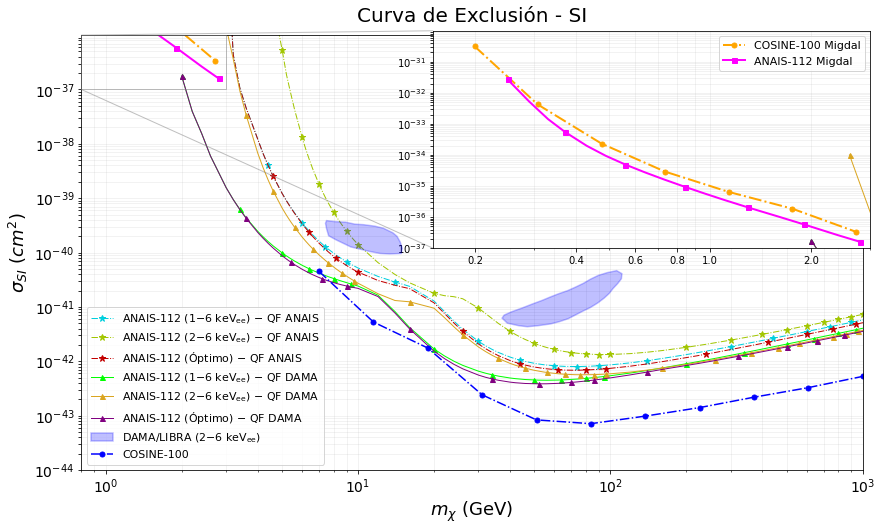

In [161]:
import itertools
from matplotlib.ticker import ScalarFormatter, NullFormatter, LogFormatterSciNotation, FuncFormatter

plt.figure(figsize=(14, 8), facecolor='white')
ax = plt.subplot()
ax.set_facecolor('white')

umbral = 1e-34

# Convertir todo a numpy
masas_opt_ANOD   = np.array(masas_opt_ANOD);   sigmas_opt_ANOD   = np.array(sigmas_opt_ANOD)
DM_16_ANOD_m     = np.array(DM_16_ANOD_m);     DM_16_ANOD        = np.array(DM_16_ANOD)
DM_26_ANOD_m     = np.array(DM_26_ANOD_m);     DM_26_ANOD        = np.array(DM_26_ANOD)
masas_opt_ANOD_D = np.array(masas_opt_ANOD_D); sigmas_opt_ANOD_D = np.array(sigmas_opt_ANOD_D)
DM_16_ANOD_m_D   = np.array(DM_16_ANOD_m_D);   DM_16_ANOD_D      = np.array(DM_16_ANOD_D)
DM_26_ANOD_m_D   = np.array(DM_26_ANOD_m_D);   DM_26_ANOD_D      = np.array(DM_26_ANOD_D)
COSINE           = np.array(COSINE)

# --- QF Tamara (dependiente de energía): líneas discontinuas ---

m = DM_16_ANOD <= umbral
ax.plot(DM_16_ANOD_m[m], DM_16_ANOD[m], linestyle='-.', linewidth=1, c="#00CFDD",marker="*", markersize=7,markevery=6, alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
m = DM_26_ANOD <= 9e-34

ax.plot(DM_26_ANOD_m[m], DM_26_ANOD[m], linestyle='-.', linewidth=1, c="#A2C600",marker="*", markersize=7,markevery=4, alpha=1,
         label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

m = sigmas_opt_ANOD <= umbral
ax.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle='-.',
        linewidth=1, c="#C20000",marker="*", markersize=7,markevery=7, alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---

m = DM_16_ANOD_D <= umbral
ax.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle='-', linewidth=1,c="lime",marker="^", markersize=5,markevery=6, alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

m = DM_26_ANOD_D <= 9e-34
ax.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle='-', linewidth=1, c="#DAA520",marker="^", markersize=5,markevery=4, alpha=1,
        label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

m = sigmas_opt_ANOD_D <= umbral
ax.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")



# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)

# COSINE normal: con máscara
m = COSINE[1] <= umbral
ax.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="-.",marker="o", markersize=5, label="COSINE-100")

# COSINE Migdal: SIN máscara
ax.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=2,
        marker="o", markersize=5, markevery=3)

ax.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=2,
        marker="s", markersize=5, markevery=3)



ax.text(0.5, 1.065, r'Curva de Exclusión - SI',
        transform=ax.transAxes,
        fontsize=20, ha='center', va='top')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=18)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=18)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-44

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(0.8,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

ax.legend(fontsize=11,loc="lower left")

ax_inset2 = ax.inset_axes([0.45, 0.51, 0.56, 0.5],alpha=0)
y_sup=1e-36
y_inf=1e-37

ax_inset2.set_ylim(y_inf,y_sup)
ax_inset2.set_xlim(0.8,3)

ax_inset2.xaxis.set_major_formatter(NullFormatter())
ax_inset2.xaxis.set_minor_formatter(NullFormatter())
ax_inset2.axis("off")   # <-- oculta marco, ticks y fondo


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]

 

ax_inset = ax.inset_axes([0.45, 0.51, 0.56, 0.5])

# COSINE Migdal: SIN máscara
ax_inset.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=2,
        marker="o", markersize=5, markevery=1,
        label="COSINE-100 Migdal")

ax_inset.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=2,
        marker="s", markersize=5, markevery=3,
        label="ANAIS-112 Migdal")

m = DM_16_ANOD_D <= umbral
ax_inset.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle='-', linewidth=1,c="lime",marker="^", markersize=5,markevery=6, alpha=1,
         )

m = DM_26_ANOD_D <= 9e-34
ax_inset.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle='-', linewidth=1, c="#DAA520",marker="^", markersize=5,markevery=4, alpha=1,
        )

m = sigmas_opt_ANOD_D <= umbral
ax_inset.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1)



ax_inset.set_yscale("log")
ax_inset.set_xscale("log")

ax_inset.legend(fontsize=11)
ax.tick_params(axis='both', labelsize=14)  # ambos ejes

y_sup=1e-30
y_inf=1e-37

ax_inset.set_ylim(y_inf,y_sup)
ax_inset.set_xlim(0.15,3)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]
#all_xticks=np.array(all_xticks)
ax_inset.set_yticks(all_ticks)   
ax_inset.set_xticks(all_xticks)  



ax_inset.xaxis.set_major_formatter(ScalarFormatter())
ax_inset.xaxis.set_minor_formatter(NullFormatter())
ax_inset.tick_params(axis='both', labelsize=10)  # ambos ejes
ax_inset.grid(which='both', linestyle='-', alpha=0.2)
ax_inset2.tick_params(axis='both', labelsize=0)  # ambos ejes
ax.indicate_inset_zoom(ax_inset2, edgecolor="grey",alpha=0.5)


print(all_ticks)
print(all_xticks)

plt.savefig("Final_SI.pdf", dpi=150, facecolor='white',bbox_inches='tight')

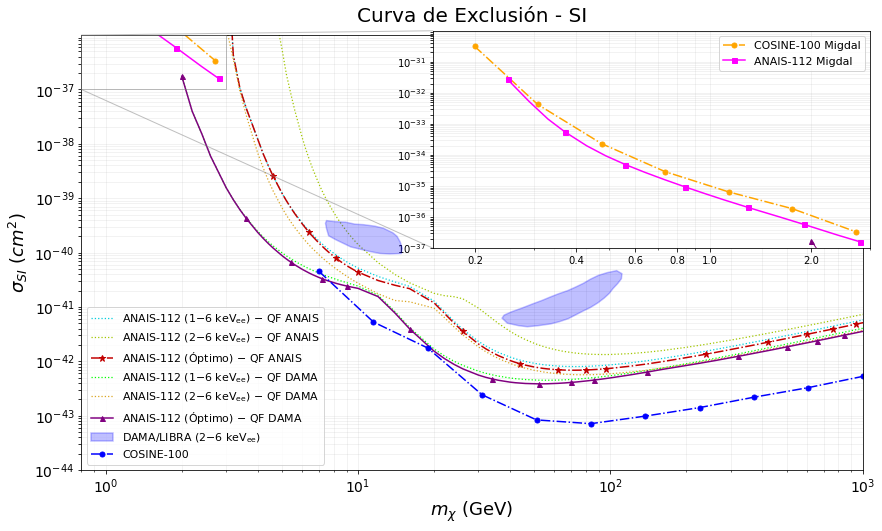

In [ ]:
import itertools
from matplotlib.ticker import ScalarFormatter, NullFormatter, LogFormatterSciNotation, FuncFormatter

plt.figure(figsize=(14, 8), facecolor='white')
ax = plt.subplot()
ax.set_facecolor('white')

umbral = 1e-34

# Convertir todo a numpy
masas_opt_ANOD   = np.array(masas_opt_ANOD);   sigmas_opt_ANOD   = np.array(sigmas_opt_ANOD)
DM_16_ANOD_m     = np.array(DM_16_ANOD_m);     DM_16_ANOD        = np.array(DM_16_ANOD)
DM_26_ANOD_m     = np.array(DM_26_ANOD_m);     DM_26_ANOD        = np.array(DM_26_ANOD)
masas_opt_ANOD_D = np.array(masas_opt_ANOD_D); sigmas_opt_ANOD_D = np.array(sigmas_opt_ANOD_D)
DM_16_ANOD_m_D   = np.array(DM_16_ANOD_m_D);   DM_16_ANOD_D      = np.array(DM_16_ANOD_D)
DM_26_ANOD_m_D   = np.array(DM_26_ANOD_m_D);   DM_26_ANOD_D      = np.array(DM_26_ANOD_D)
COSINE           = np.array(COSINE)

# --- QF Tamara (dependiente de energía): líneas discontinuas ---

m = DM_16_ANOD <= umbral
ax.plot(DM_16_ANOD_m[m], DM_16_ANOD[m], linestyle=':', linewidth=1.25, c="#00CFDD", alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
m = DM_26_ANOD <= 9e-34

ax.plot(DM_26_ANOD_m[m], DM_26_ANOD[m], linestyle=':', linewidth=1.25, c="#A2C600", alpha=1,
         label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

m = sigmas_opt_ANOD <= umbral
ax.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle='-.',
        linewidth=1.5, c="#C20000",marker="*", markersize=7,markevery=7, alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---

m = DM_16_ANOD_D <= umbral
ax.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle=':', linewidth=1.25,c="lime", alpha=1,
         label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

m = DM_26_ANOD_D <= 9e-34
ax.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle=':', linewidth=1.25, c="#DAA520", alpha=1,
        label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

m = sigmas_opt_ANOD_D <= umbral
ax.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1.5,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")



# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)

# COSINE normal: con máscara
m = COSINE[1] <= umbral
ax.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="-.",marker="o", markersize=5, label="COSINE-100", linewidth=1.5)

# COSINE Migdal: SIN máscara
ax.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=1.5,
        marker="o", markersize=5, markevery=3)

ax.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=1.5,
        marker="s", markersize=5, markevery=3)



ax.text(0.5, 1.065, r'Curva de Exclusión - SI',
        transform=ax.transAxes,
        fontsize=20, ha='center', va='top')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=18)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=18)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-44

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(0.8,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

ax.legend(fontsize=11,loc="lower left")

ax_inset2 = ax.inset_axes([0.45, 0.51, 0.56, 0.5],alpha=0)
y_sup=1e-36
y_inf=1e-37

ax_inset2.set_ylim(y_inf,y_sup)
ax_inset2.set_xlim(0.8,3)

ax_inset2.xaxis.set_major_formatter(NullFormatter())
ax_inset2.xaxis.set_minor_formatter(NullFormatter())
ax_inset2.axis("off")   # <-- oculta marco, ticks y fondo


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]

 

ax_inset = ax.inset_axes([0.45, 0.51, 0.56, 0.5])

# COSINE Migdal: SIN máscara
ax_inset.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=1.5,
        marker="o", markersize=5, markevery=1,
        label="COSINE-100 Migdal")

ax_inset.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=1.5,
        marker="s", markersize=5, markevery=3,
        label="ANAIS-112 Migdal")


m = sigmas_opt_ANOD_D <= umbral
ax_inset.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1)



ax_inset.set_yscale("log")
ax_inset.set_xscale("log")

ax_inset.legend(fontsize=11)
ax.tick_params(axis='both', labelsize=14)  # ambos ejes

y_sup=1e-30
y_inf=1e-37

ax_inset.set_ylim(y_inf,y_sup)
ax_inset.set_xlim(0.15,3)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]
#all_xticks=np.array(all_xticks)
ax_inset.set_yticks(all_ticks)   
ax_inset.set_xticks(all_xticks)  



ax_inset.xaxis.set_major_formatter(ScalarFormatter())
ax_inset.xaxis.set_minor_formatter(NullFormatter())
ax_inset.tick_params(axis='both', labelsize=10)  # ambos ejes
ax_inset.grid(which='both', linestyle='-', alpha=0.2)
ax_inset2.tick_params(axis='both', labelsize=0)  # ambos ejes
ax.indicate_inset_zoom(ax_inset2, edgecolor="grey",alpha=0.5)




plt.savefig("Final_SI_3.pdf", dpi=150, facecolor='white',bbox_inches='tight')

[1.e-37 2.e-37 3.e-37 4.e-37 5.e-37 6.e-37 7.e-37 8.e-37 9.e-37 1.e-36
 2.e-36 3.e-36 4.e-36 5.e-36 6.e-36 7.e-36 8.e-36 9.e-36 1.e-35 2.e-35
 3.e-35 4.e-35 5.e-35 6.e-35 7.e-35 8.e-35 9.e-35 1.e-34 2.e-34 3.e-34
 4.e-34 5.e-34 6.e-34 7.e-34 8.e-34 9.e-34 1.e-33 2.e-33 3.e-33 4.e-33
 5.e-33 6.e-33 7.e-33 8.e-33 9.e-33 1.e-32 2.e-32 3.e-32 4.e-32 5.e-32
 6.e-32 7.e-32 8.e-32 9.e-32 1.e-31 2.e-31 3.e-31 4.e-31 5.e-31 6.e-31
 7.e-31 8.e-31 9.e-31]
[0.2, 0.4, 0.6, 0.8, 1.0, 2.0]


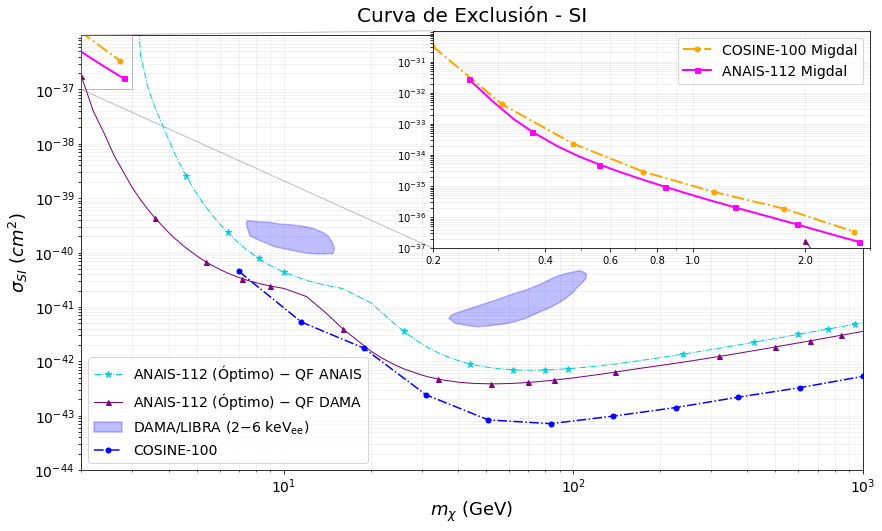

In [163]:
import itertools
from matplotlib.ticker import ScalarFormatter, NullFormatter, LogFormatterSciNotation, FuncFormatter

plt.figure(figsize=(14, 8), facecolor='white')
ax = plt.subplot()
ax.set_facecolor('white')

umbral = 1e-34

# Convertir todo a numpy
masas_opt_ANOD   = np.array(masas_opt_ANOD);   sigmas_opt_ANOD   = np.array(sigmas_opt_ANOD)
DM_16_ANOD_m     = np.array(DM_16_ANOD_m);     DM_16_ANOD        = np.array(DM_16_ANOD)
DM_26_ANOD_m     = np.array(DM_26_ANOD_m);     DM_26_ANOD        = np.array(DM_26_ANOD)
masas_opt_ANOD_D = np.array(masas_opt_ANOD_D); sigmas_opt_ANOD_D = np.array(sigmas_opt_ANOD_D)
DM_16_ANOD_m_D   = np.array(DM_16_ANOD_m_D);   DM_16_ANOD_D      = np.array(DM_16_ANOD_D)
DM_26_ANOD_m_D   = np.array(DM_26_ANOD_m_D);   DM_26_ANOD_D      = np.array(DM_26_ANOD_D)
COSINE           = np.array(COSINE)

# --- QF Tamara (dependiente de energía): líneas discontinuas ---



m = sigmas_opt_ANOD <= umbral
ax.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle='-.',
        linewidth=1, c="#00CFDD",marker="*", markersize=7,markevery=7, alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---


m = sigmas_opt_ANOD_D <= umbral
ax.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")



# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)

# COSINE normal: con máscara
m = COSINE[1] <= umbral
ax.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="-.",marker="o", markersize=5, label="COSINE-100")

# COSINE Migdal: SIN máscara
ax.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=2,
        marker="o", markersize=5, markevery=3)

ax.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=2,
        marker="s", markersize=5, markevery=3)



ax.text(0.5, 1.065, r'Curva de Exclusión - SI',
        transform=ax.transAxes,
        fontsize=20, ha='center', va='top')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=18)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=18)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-36
y_inf=1e-44

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(2,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

ax.legend(fontsize=14,loc="lower left")

ax_inset2 = ax.inset_axes([0.45, 0.51, 0.56, 0.5],alpha=0)
y_sup=1e-36
y_inf=1e-37

ax_inset2.set_ylim(y_inf,y_sup)
ax_inset2.set_xlim(2,3)

ax_inset2.xaxis.set_major_formatter(NullFormatter())
ax_inset2.xaxis.set_minor_formatter(NullFormatter())
ax_inset2.axis("off")   # <-- oculta marco, ticks y fondo


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]

 

ax_inset = ax.inset_axes([0.45, 0.51, 0.56, 0.5])

# COSINE Migdal: SIN máscara
ax_inset.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], color="orange", linestyle="-.", linewidth=2,
        marker="o", markersize=5, markevery=1,
        label="COSINE-100 Migdal")

ax_inset.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], color="magenta", linestyle="-", linewidth=2,
        marker="s", markersize=5, markevery=3,
        label="ANAIS-112 Migdal")


m = sigmas_opt_ANOD_D <= umbral
ax_inset.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=1,
        c="purple",marker="^", markersize=5,markevery=7, alpha=1)



ax_inset.set_yscale("log")
ax_inset.set_xscale("log")

ax_inset.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=14)  # ambos ejes

y_sup=1e-30
y_inf=1e-37

ax_inset.set_ylim(y_inf,y_sup)
ax_inset.set_xlim(2,3)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)
all_xticks=[2e-1,4e-1,6e-1,8e-1,1e0,2e0]
#all_xticks=np.array(all_xticks)
ax_inset.set_yticks(all_ticks)   
ax_inset.set_xticks(all_xticks)  



ax_inset.xaxis.set_major_formatter(ScalarFormatter())
ax_inset.xaxis.set_minor_formatter(NullFormatter())
ax_inset.tick_params(axis='both', labelsize=10)  # ambos ejes
ax_inset.grid(which='both', linestyle='-', alpha=0.2)
ax_inset2.tick_params(axis='both', labelsize=0)  # ambos ejes
ax.indicate_inset_zoom(ax_inset2, edgecolor="grey",alpha=0.5)


print(all_ticks)
print(all_xticks)

plt.savefig("Final_SI_2.pdf", dpi=150, facecolor='white',bbox_inches='tight')

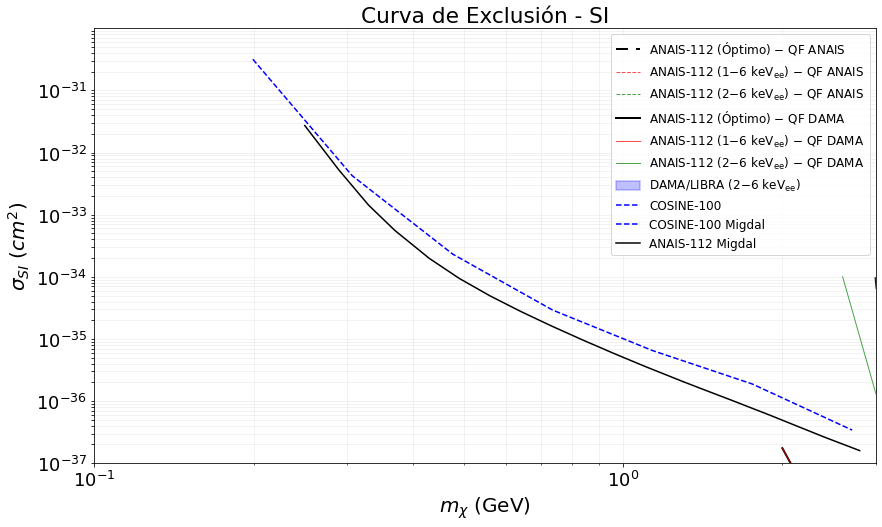

In [164]:
import itertools
plt.figure(figsize=(14, 8), facecolor='white')
ax = plt.subplot()
ax.set_facecolor('white')

umbral = 1e-34

# Convertir todo a numpy
masas_opt_ANOD   = np.array(masas_opt_ANOD);   sigmas_opt_ANOD   = np.array(sigmas_opt_ANOD)
DM_16_ANOD_m     = np.array(DM_16_ANOD_m);     DM_16_ANOD        = np.array(DM_16_ANOD)
DM_26_ANOD_m     = np.array(DM_26_ANOD_m);     DM_26_ANOD        = np.array(DM_26_ANOD)
masas_opt_ANOD_D = np.array(masas_opt_ANOD_D); sigmas_opt_ANOD_D = np.array(sigmas_opt_ANOD_D)
DM_16_ANOD_m_D   = np.array(DM_16_ANOD_m_D);   DM_16_ANOD_D      = np.array(DM_16_ANOD_D)
DM_26_ANOD_m_D   = np.array(DM_26_ANOD_m_D);   DM_26_ANOD_D      = np.array(DM_26_ANOD_D)
COSINE           = np.array(COSINE)

# --- QF Tamara (dependiente de energía): líneas discontinuas ---
m = sigmas_opt_ANOD <= umbral
ax.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle=(0, (6, 4, 6, 4)),
        linewidth=2, c="black", alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")
m = DM_16_ANOD <= umbral
ax.plot(DM_16_ANOD_m[m], DM_16_ANOD[m], linestyle='--', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
m = DM_26_ANOD <= 9e-34
ax.plot(DM_26_ANOD_m[m], DM_26_ANOD[m], linestyle='--', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---
m = sigmas_opt_ANOD_D <= umbral
ax.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=2,
        c="black", alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")
m = DM_16_ANOD_D <= umbral
ax.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle='-', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")
m = DM_26_ANOD_D <= 9e-34
ax.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle='-', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)

# COSINE normal: con máscara
m = COSINE[1] <= umbral
ax.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="--", label="COSINE-100")

# COSINE Migdal: SIN máscara
ax.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], c='blue', linestyle="--",
        label="COSINE-100 Migdal")

ax.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], c='black', linestyle="-",
        label="ANAIS-112 Migdal")

ax.legend(fontsize=12)

ax.set_title(r'Curva de Exclusión - SI')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-30
y_inf=1e-37

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(0.1,3)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

#plt.savefig("Final_SI.pdf", dpi=150, facecolor='white',bbox_inches='tight')

(<matplotlib.patches.Rectangle at 0x7b54bf92b400>,
 (<matplotlib.patches.ConnectionPatch at 0x7b54bdff4790>,
  <matplotlib.patches.ConnectionPatch at 0x7b54bdffd1c0>))

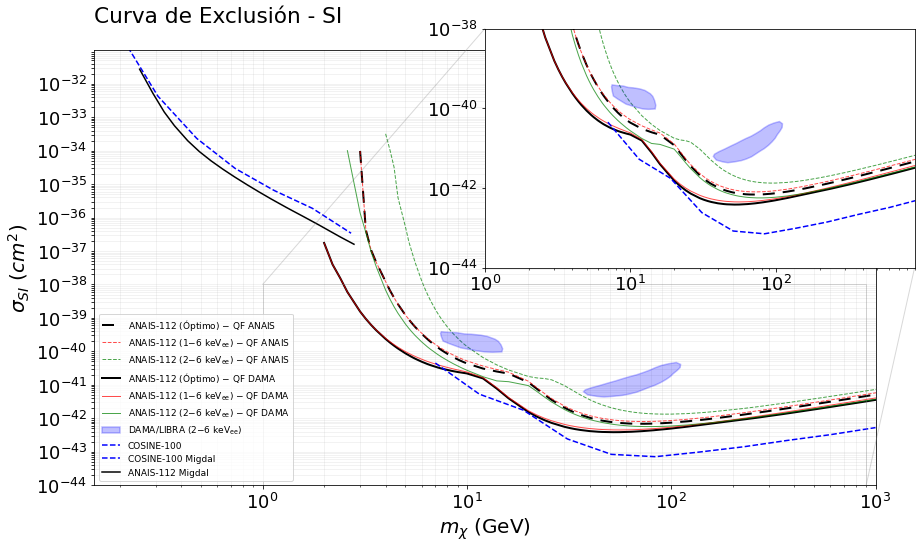

In [165]:
import itertools
plt.figure(figsize=(14, 8), facecolor='white')
ax = plt.subplot()
ax.set_facecolor('white')

umbral = 1e-34

# Convertir todo a numpy
masas_opt_ANOD   = np.array(masas_opt_ANOD);   sigmas_opt_ANOD   = np.array(sigmas_opt_ANOD)
DM_16_ANOD_m     = np.array(DM_16_ANOD_m);     DM_16_ANOD        = np.array(DM_16_ANOD)
DM_26_ANOD_m     = np.array(DM_26_ANOD_m);     DM_26_ANOD        = np.array(DM_26_ANOD)
masas_opt_ANOD_D = np.array(masas_opt_ANOD_D); sigmas_opt_ANOD_D = np.array(sigmas_opt_ANOD_D)
DM_16_ANOD_m_D   = np.array(DM_16_ANOD_m_D);   DM_16_ANOD_D      = np.array(DM_16_ANOD_D)
DM_26_ANOD_m_D   = np.array(DM_26_ANOD_m_D);   DM_26_ANOD_D      = np.array(DM_26_ANOD_D)
COSINE           = np.array(COSINE)

# --- QF Tamara (dependiente de energía): líneas discontinuas ---
m = sigmas_opt_ANOD <= umbral
ax.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle=(0, (6, 4, 6, 4)),
        linewidth=2, c="black", alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")
m = DM_16_ANOD <= umbral
ax.plot(DM_16_ANOD_m[m], DM_16_ANOD[m], linestyle='--', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
m = DM_26_ANOD <= 9e-34
ax.plot(DM_26_ANOD_m[m], DM_26_ANOD[m], linestyle='--', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---
m = sigmas_opt_ANOD_D <= umbral
ax.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=2,
        c="black", alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")
m = DM_16_ANOD_D <= umbral
ax.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle='-', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")
m = DM_26_ANOD_D <= 9e-34
ax.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle='-', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

# --- Regiones DAMA/LIBRA ---
ax.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5)

# COSINE normal: con máscara
m = COSINE[1] <= umbral
ax.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="--", label="COSINE-100")

# COSINE Migdal: SIN máscara
ax.plot(COSINE_MIGDAL[0], COSINE_MIGDAL[1], c='blue', linestyle="--",
        label="COSINE-100 Migdal")

ax.plot(ANAIS_MIGDAL[0], ANAIS_MIGDAL[1], c='black', linestyle="-",
        label="ANAIS-112 Migdal")

ax.legend(fontsize=9, loc='lower left')


ax.set_title(r'Curva de Exclusión - SI',loc="left")
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_\chi$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-31
y_inf=1e-44

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(0.15,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     

all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)

ax_inset = ax.inset_axes([0.5, 0.5, 0.55, 0.55])

m = sigmas_opt_ANOD <= umbral
ax_inset.plot(masas_opt_ANOD[m], sigmas_opt_ANOD[m], linestyle=(0, (6, 4, 6, 4)),
        linewidth=2, c="black", alpha=1,
        label="ANAIS-112 (Óptimo) $-$ QF ANAIS")
m = DM_16_ANOD <= umbral
ax_inset.plot(DM_16_ANOD_m[m], DM_16_ANOD[m], linestyle='--', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")
m = DM_26_ANOD <= 9e-34
ax_inset.plot(DM_26_ANOD_m[m], DM_26_ANOD[m], linestyle='--', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF ANAIS")

# --- QF DAMA (constante): líneas continuas ---
m = sigmas_opt_ANOD_D <= umbral
ax_inset.plot(masas_opt_ANOD_D[m], sigmas_opt_ANOD_D[m], linestyle='-', linewidth=2,
        c="black", alpha=1, label="ANAIS-112 (Óptimo) $-$ QF DAMA")
m = DM_16_ANOD_D <= umbral
ax_inset.plot(DM_16_ANOD_m_D[m], DM_16_ANOD_D[m], linestyle='-', linewidth=1, c="red",
        alpha=0.7, label="ANAIS-112 (1$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")
m = DM_26_ANOD_D <= 9e-34
ax_inset.plot(DM_26_ANOD_m_D[m], DM_26_ANOD_D[m], linestyle='-', linewidth=1, c="green",
        alpha=0.7, label="ANAIS-112 (2$-$6 $\\mathrm{keV_{ee}}$) $-$ QF DAMA")

# --- Regiones DAMA/LIBRA ---
ax_inset.fill(DAMA1_x, DAMA1_y, facecolor='blue', zorder=10, alpha=0.25,
        edgecolor='blue', linewidth=1.5, label="DAMA/LIBRA (2$-$6 $\\mathrm{keV_{ee}}$)")
ax_inset.fill(DAMA2_x, DAMA2_y, facecolor='blue', zorder=10, alpha=0.25,edgecolor='blue', linewidth=1.5)
              

m = COSINE[1] <= umbral
ax_inset.plot(COSINE[0][m], COSINE[1][m], c='blue', linestyle="--", label="COSINE-100")
        

ax_inset.set_xscale("log")
ax_inset.set_yscale("log")
ax_inset.set_xlim(1, 900)
ax_inset.set_ylim(1e-44, 1e-38)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     



ax.indicate_inset_zoom(ax_inset, edgecolor="gray",alpha=0.3)

#plt.savefig("Final_SI.pdf", dpi=150, facecolor='white',bbox_inches='tight')